Load segmented nail crop dataset

In [9]:
from pathlib import Path
import pandas as pd

NO_POLISH_DIR = Path("/Users/williamtsai/Desktop/nail_unusable_classifier/dataset/usable_nail_only_png")
POLISH_DIR = Path("/Users/williamtsai/Desktop/nail_unusable_classifier/dataset/nail_polish_nail_only_png")

image_exts = {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

no_polish_files = sorted([
    p for p in NO_POLISH_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
])

polish_files = sorted([
    p for p in POLISH_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
])

print("No polish images:", len(no_polish_files))
print("Polish images   :", len(polish_files))

df_no = pd.DataFrame({
    "filepath": [str(p) for p in no_polish_files],
    "label": 0,
    "class_name": "no_polish"
})

df_yes = pd.DataFrame({
    "filepath": [str(p) for p in polish_files],
    "label": 1,
    "class_name": "polish"
})

df = pd.concat([df_no, df_yes], ignore_index=True)

print("\nOriginal class counts:")
print(df["class_name"].value_counts())

df_balanced = df  # keep all data, no downsampling
print("\nFull class counts:")
print(df_balanced["class_name"].value_counts())

No polish images: 3508
Polish images   : 402

Original class counts:
class_name
no_polish    3508
polish        402
Name: count, dtype: int64

Full class counts:
class_name
no_polish    3508
polish        402
Name: count, dtype: int64


Create group-based train/validation/test split

In [10]:
from sklearn.model_selection import GroupShuffleSplit
from collections import Counter
from pathlib import Path
import re
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

# =========================
# CREATE GROUP ID
# =========================
# Keeps crops from the same original image together.
# Examples:
# xxx_nail_01.png -> xxx
# xxx_nail_02.png -> xxx
# xxx_01.png      -> xxx

def get_group_id(filepath):
    stem = Path(filepath).stem

    # remove common crop suffixes
    stem = re.sub(r"_nail_\d+$", "", stem)
    stem = re.sub(r"_\d+$", "", stem)

    return stem

df_balanced = df_balanced.copy()
df_balanced["group_id"] = df_balanced["filepath"].apply(get_group_id)

print("Total samples:", len(df_balanced))
print("Total groups :", df_balanced["group_id"].nunique())
print("\nClass counts:")
print(df_balanced["class_name"].value_counts())

# =========================
# GROUP SPLIT: 70% train, 30% temp
# =========================

gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss1.split(
        df_balanced,
        groups=df_balanced["group_id"]
    )
)

train_df = df_balanced.iloc[train_idx].reset_index(drop=True)
temp_df = df_balanced.iloc[temp_idx].reset_index(drop=True)

# =========================
# GROUP SPLIT TEMP: 15% val, 15% test
# =========================

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["group_id"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# =========================
# CHECK SPLIT
# =========================

print("\nTrain:", len(train_df), Counter(train_df["label"]))
print("Val  :", len(val_df), Counter(val_df["label"]))
print("Test :", len(test_df), Counter(test_df["label"]))

train_groups = set(train_df["group_id"])
val_groups = set(val_df["group_id"])
test_groups = set(test_df["group_id"])

print("\nGroup overlap check:")
print("train ∩ val :", len(train_groups & val_groups))
print("train ∩ test:", len(train_groups & test_groups))
print("val ∩ test  :", len(val_groups & test_groups))

print("\nGroup counts:")
print("Train groups:", len(train_groups))
print("Val groups  :", len(val_groups))
print("Test groups :", len(test_groups))

Total samples: 3910
Total groups : 942

Class counts:
class_name
no_polish    3508
polish        402
Name: count, dtype: int64

Train: 2722 Counter({0: 2426, 1: 296})
Val  : 593 Counter({0: 549, 1: 44})
Test : 595 Counter({0: 533, 1: 62})

Group overlap check:
train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0

Group counts:
Train groups: 659
Val groups  : 141
Test groups : 142


Define image transforms and dataset loader

In [16]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class NailPolishDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["filepath"]
        label = int(row["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = NailPolishDataset(train_df, transform=train_transform)
val_dataset = NailPolishDataset(val_df, transform=eval_transform)
test_dataset = NailPolishDataset(test_df, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

class_names = ["no_polish", "polish"]
idx_to_label = {0: "no_polish", 1: "polish"}

print("DataLoaders ready.")

DataLoaders ready.


Set up ResNet18 transfer learning model

In [17]:
import torch.nn as nn
from torchvision import models

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

n_no = len(df_no)
n_polish = len(df_yes)

weight_tensor = torch.tensor([1.0, n_no / n_polish]).to(device)
criterion = nn.CrossEntropyLoss(weight=weight_tensor)

optimizer = torch.optim.Adam(
    list(model.layer3.parameters()) + list(model.layer4.parameters()) + list(model.fc.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print("Model ready: training layer4 + fc.")

Device: mps
Model ready: training layer4 + fc.


Train model and save best validation checkpoint

In [19]:
from tqdm import tqdm
import copy

num_epochs = 20
best_val_acc = 0.0
best_model_path = best_model_path = "best_segmented_polish_classifier_group_split_v2.pth"

history = {
    "train_acc": [],
    "val_acc": [],
    "train_loss": [],
    "val_loss": []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    # =========================
    # TRAIN
    # =========================
    model.train()
    train_correct = 0
    train_total = 0
    train_loss_total = 0.0

    for images, labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        train_loss_total += loss.item() * labels.size(0)

    train_acc = train_correct / train_total
    train_loss = train_loss_total / train_total

    # =========================
    # VALIDATION
    # =========================
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss_total = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_loss_total += loss.item() * labels.size(0)

    val_acc = val_correct / val_total
    val_loss = val_loss_total / val_total

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")
    print(f"Val loss  : {val_loss:.4f}, Val acc  : {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Saved new best model.")

    scheduler.step()

print("\nBest validation accuracy:", best_val_acc)
print("Best model saved to:", best_model_path)


Epoch 1/20


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:03<00:00,  9.53it/s]


Train loss: 0.0107, Train acc: 0.9982
Val loss  : 0.1158, Val acc  : 0.9646
Saved new best model.

Epoch 2/20


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:03<00:00,  9.62it/s]


Train loss: 0.0151, Train acc: 0.9978
Val loss  : 0.1168, Val acc  : 0.9646

Epoch 3/20


...

Train loss: 0.0378, Train acc: 0.9875
Val loss  : 0.1775, Val acc  : 0.9393

Epoch 19/20


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:02<00:00, 15.65it/s]


Train loss: 0.0292, Train acc: 0.9912
Val loss  : 0.1222, Val acc  : 0.9629

Epoch 20/20


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:02<00:00, 15.15it/s]

Train loss: 0.0183, Train acc: 0.9945
Val loss  : 0.0900, Val acc  : 0.9713

Best validation accuracy: 0.9747048903878583
Best model saved to: best_segmented_polish_classifier_group_split_v2.pth


Plot training and validation accuracy/loss

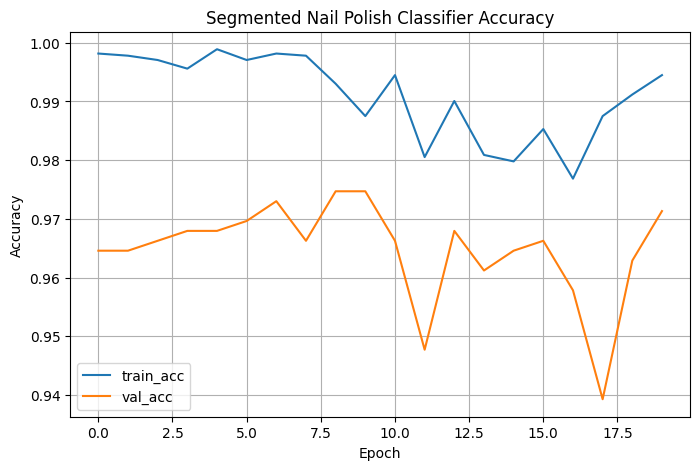

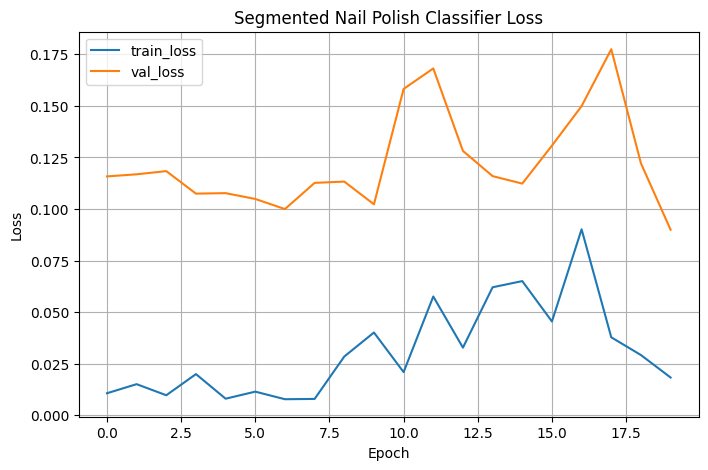

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Segmented Nail Polish Classifier Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Segmented Nail Polish Classifier Loss")
plt.legend()
plt.grid(True)
plt.show()

Evaluate final model on test set

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

print("Test accuracy:", accuracy_score(all_labels, all_preds))

print("\nConfusion matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

Testing: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:02<00:00, 14.72it/s]

Test accuracy: 0.9865546218487395

Confusion matrix:
[[531   2]
 [  6  56]]

Classification report:
              precision    recall  f1-score   support

   no_polish       0.99      1.00      0.99       533
      polish       0.97      0.90      0.93        62

    accuracy                           0.99       595
   macro avg       0.98      0.95      0.96       595
weighted avg       0.99      0.99      0.99       595

